In [95]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 

In [96]:
# PHYSICAl CONSTANTS

# M_E = 9.1093837015e-31 # electron mass in kg
M_E = 0.511 # electron mass in MeV/c^2
Q_E_SI = -1.602176634e-19 # electron charge in C
Q_E = -1. # electron charge in e
EPSILON_0 = 5.5263494e13  # vacuum permittivity in in e/(MV*m)
C_SI = 299792458 # speed of light in m/s
C = 1. # speed of light in (MeV*m/e)

# HYPERPARAMETERS

SIGMA_X=1e-3 # standard deviation of initial x position in m
SIGMA_Y=1e-3 # standard deviation of initial y position in m
SIGMA_Z=0.1 # standard deviation of initial z position in m

SIGMA_PX=1e-9 # standard deviation of initial x momentum in MeV/c
SIGMA_PY=1e-9 # standard deviation of initial y momentum in MeV/c
SIGMA_PZ=1e-2 # standard deviation of initial z momentum in MeV/c


LENGTH_PRIOR = 0.0 # length of prior region to be modeled in m
LENGTH_D = 0.25 # length of drift chamber in m
LENGTH_E = 3.75 # length of electric field chamber in m
LENGTH_POSTERIOR = 1.5 # length of posterior region to be modeled in m

E_Z = -1.

N_P = int(1e2) # number of macro particles
TOTAL_CHARGE_SI = 1e-9 # total bunch charge in C


# DERIVED QUANTITIES

POSITION_SIGMA = (SIGMA_X, SIGMA_Y, SIGMA_Z)
MOMENTUM_SIGMA = (SIGMA_PX, SIGMA_PY, SIGMA_PZ)

Z_START = 0. # start of model space
Z_0 = Z_START + LENGTH_PRIOR # initial z position of particles
Z_1 = Z_START + LENGTH_PRIOR + LENGTH_D # z position of end of drift chamber = start of electric field chamber
Z_2 = Z_START + LENGTH_PRIOR + LENGTH_D + LENGTH_E # z position of end of electric field chamber
Z_END = Z_2 + LENGTH_POSTERIOR # end of model space

POSITION_0 = (0., 0., Z_0) # initial position (of reference particle) in m
MOMENTUM_0 = (0., 0., 0.1) # initial momentum in MeV/c

N_REAL_ELECTRONS = TOTAL_CHARGE_SI / Q_E_SI # number of real electrons in the bunch
MACRO_WEIGHT = N_REAL_ELECTRONS / N_P 

M_MACRO = M_E * MACRO_WEIGHT
Q_MACRO = Q_E * MACRO_WEIGHT

### Helper Functions

In [97]:
def gamma(p):
    '''
    Calculate relativistic gamma factor from particle momentum

    Returns scalar
    '''
    p_squared = np.sum(p**2)
    gamma = np.sqrt(1. + (p_squared / M_E**2))

    return gamma

def v_SI(p):
    return (p / (gamma(p) * M_E)) * C_SI 

    


def gamma_particles(momentum_particles):
    '''
    Calculate relativistic gamma factor from particle momentum

    Returns np.array of shape (N_P,1)
    '''
    p_squared = np.sum(momentum_particles**2, axis=1, keepdims=True)
    gamma = np.sqrt(1. + (p_squared / M_E**2))

    return gamma


    

# 1 Particle

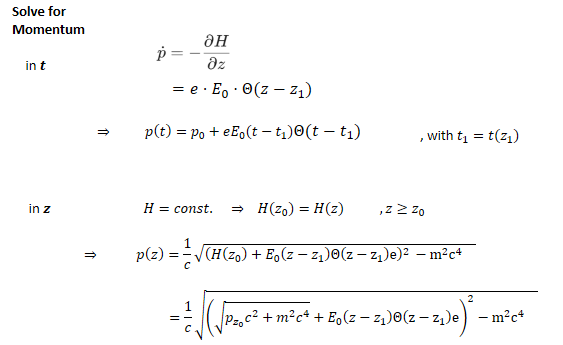

In [98]:
def p_of_t_1d(t, p_0):
    t_1 = Z_1 / v_SI(p_0)
    
    if t < t_1:
        return p_0
    else:
        return p_0 + Q_E * E_Z * (t - t_1)
    
def p_of_z_1d(z, p_0):
    if z < Z_1:
        return (1/C) * np.sqrt((p_0**2*C**2 + M_E**2*C**4) - M_E**2 * C**4)
    if z >= Z_1:
        return (1/C) * np.sqrt((np.sqrt(p_0**2*C**2 + M_E**2*C**4) + Q_E*E_Z*(z-Z_1) )**2 - M_E**2 * C**4)

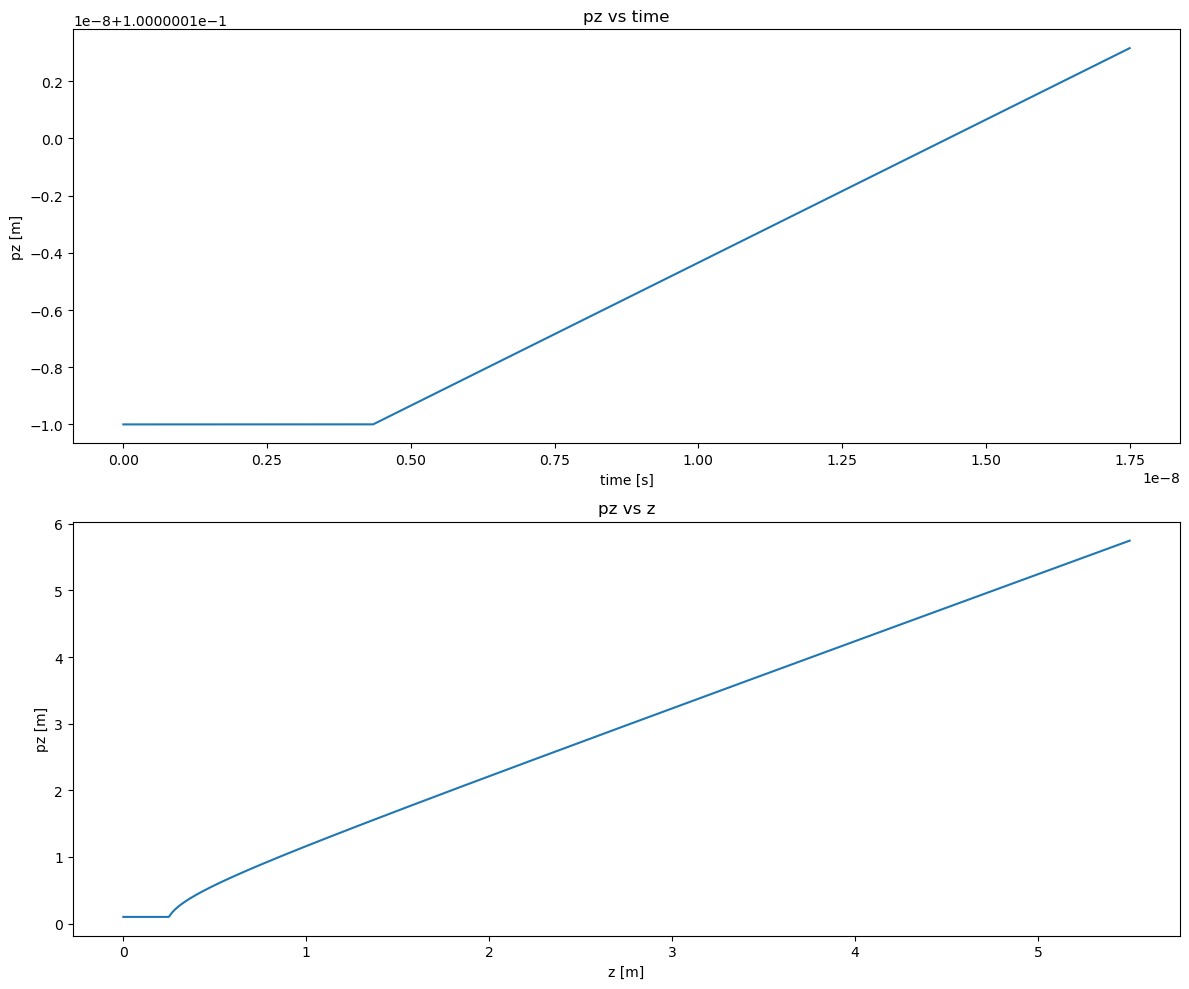

In [99]:
fig, axes = plt.subplots(2, figsize=(12, 10))

t_end = 1.75e-8
p_0 = MOMENTUM_0[2]
times = np.linspace(0., t_end, 1000)
momenta_vs_time = np.array([p_of_t_1d(t, p_0) for t in times]) 

axes[0].plot(times, momenta_vs_time)
axes[0].set_xlabel('time [s]')
axes[0].set_ylabel(f'pz [m]')
axes[0].set_title(f'pz vs time')

positions = np.linspace(Z_START, Z_END, 1000)
momenta_vs_position = np.array([p_of_z_1d(z, p_0) for z in positions])

axes[1].plot(positions, momenta_vs_position)
axes[1].set_xlabel('z [m]')
axes[1].set_ylabel(f'pz [m]')
axes[1].set_title(f'pz vs z')

plt.tight_layout()
plt.show()


# N Particles

### 1D

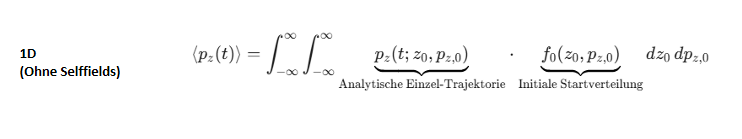
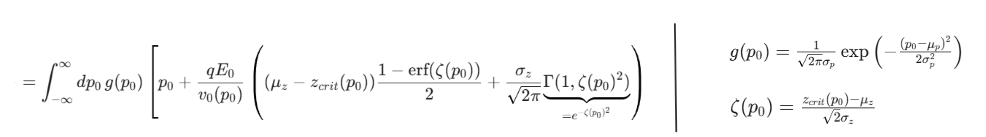

In [ ]:
from scipy.integrate import quad
from scipy.special import erf

# TODO: Particles starting in the E-field already by chance are not correctly modeled

def mu_p_of_t_1d(t, mu_z0, sigma_z0, mu_p0, sigma_p0):

    
    def integrand(p0):
        g0 = 1/(np.sqrt(2*np.pi)*sigma_p0) * np.exp(- (p0 - mu_p0)**2 / (2*sigma_p0**2))

        v0_SI = v_SI(p0)
        v0 = v0_SI / C_SI

        z_crit = Z_1 - v0_SI * t
        
        zeta = (z_crit - mu_z0) / (np.sqrt(2) * sigma_z0)
        
        bracket = (Q_E*E_Z/v0) * (
            (mu_z0 - z_crit) * ((1.0 - erf(zeta)) / 2.0) + 
            (sigma_z0 / np.sqrt(2 * np.pi)) * np.exp(-zeta**2)
        )

        return g0 * bracket
    
    # integral, error = quad(integrand, -np.inf, np.inf)
    integral, error = quad(integrand, mu_p0-sigma_p0*10.0, mu_p0+sigma_p0*10.0) # restrict integration limits to yields finer resolution



    # we can compute p_0 out of the integrate, yielding a constant mu_p0 

    return mu_p0 + integral


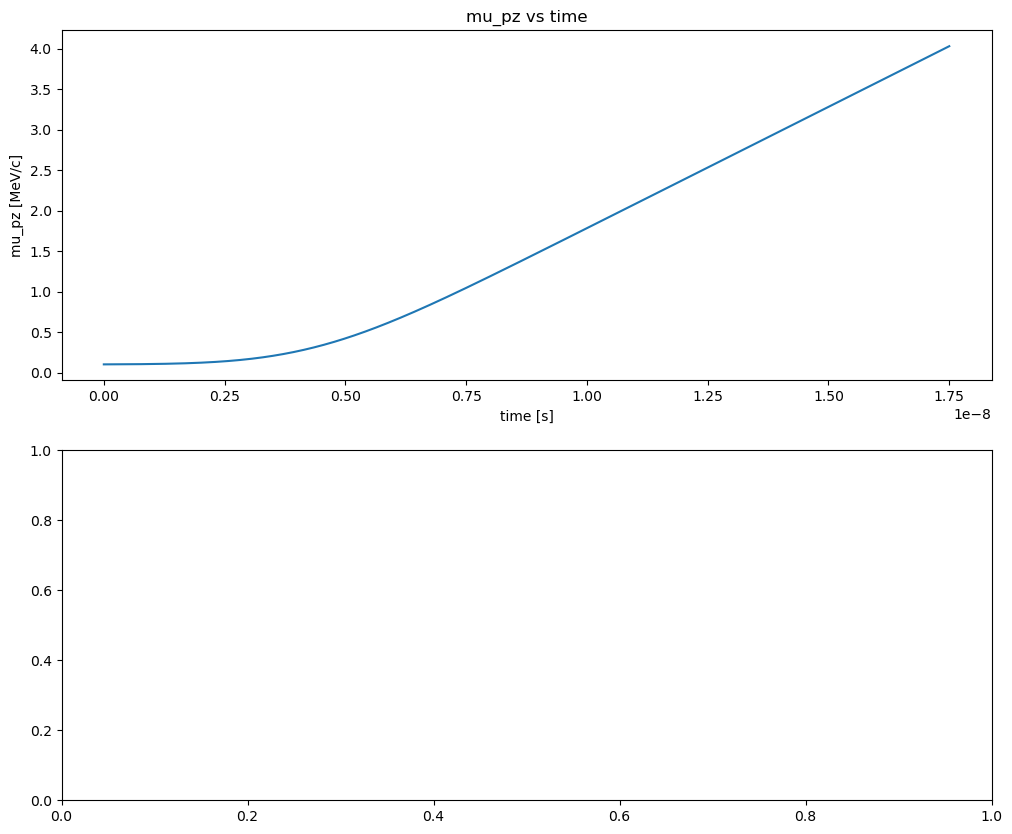

In [101]:
fig, axes = plt.subplots(2, figsize=(12, 10))

times = np.linspace(0., t_end, 1000)
mu_p_vs_time = np.array([mu_p_of_t_1d(t, POSITION_0[2], POSITION_SIGMA[2], MOMENTUM_0[2], MOMENTUM_SIGMA[2]) for t in times])

axes[0].plot(times, mu_p_vs_time)
axes[0].set_xlabel('time [s]')
axes[0].set_ylabel(f'mu_pz [MeV/c]')
axes[0].set_title(f'mu_pz vs time')
# axes[0].ticklabel_format(useOffset=False, style='plain')

positions = np.linspace(Z_START, Z_END, 1000)
